In [17]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
X = df.drop("Glucose", axis=1)
y = df["Glucose"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
models = [lr, ridge, lasso]
names = ["Linear Regression", "Ridge", "Lasso"]
colors = ["steelblue", "darkorange", "mediumseagreen"]

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [22]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)   # ← THIS LINE IS CRUCIAL

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model_name, y_true, pred):
    mae = mean_absolute_error(y_true, pred)
    mse = mean_squared_error(y_true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred)

    print(f"{model_name}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MSE  = {mse:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R2   = {r2:.4f}")
    print()

# Calling function
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Ridge Regression (alpha=1.0)", y_test, ridge_pred)
evaluate("Lasso Regression (alpha=0.5)", y_test, lasso_pred)

Linear Regression
  MAE  = 20.6074
  MSE  = 704.6762
  RMSE = 26.5457
  R2   = 0.2997

Ridge Regression (alpha=1.0)
  MAE  = 20.6151
  MSE  = 704.9065
  RMSE = 26.5501
  R2   = 0.2995

Lasso Regression (alpha=0.5)
  MAE  = 20.6522
  MSE  = 701.5852
  RMSE = 26.4875
  R2   = 0.3028



In [24]:
import pandas as pd

lasso_coef = pd.Series(lasso.coef_, index=X.columns)

print("Removed Features:")
print(lasso_coef[lasso_coef == 0])

Removed Features:
Series([], dtype: float64)


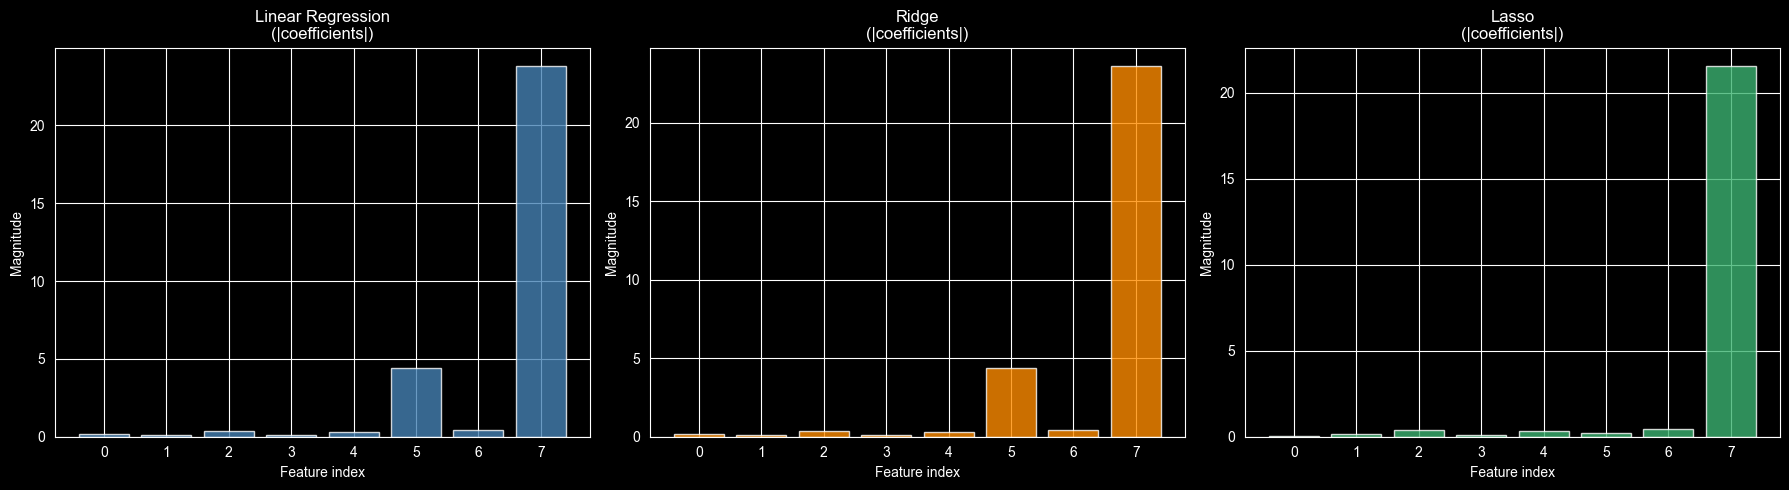

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name, color in zip(axes, models, names, colors):
    ax.bar(range(len(model.coef_)), np.abs(model.coef_), color=color, alpha=0.8)
    ax.set_title(f"{name}\n(|coefficients|)")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_12568\2645166096.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=45)
C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_12568\2645166096.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=45)
C:\Users\VANSHITHA\AppData\Local\Temp\ipykernel_12568\2645166096.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=45)


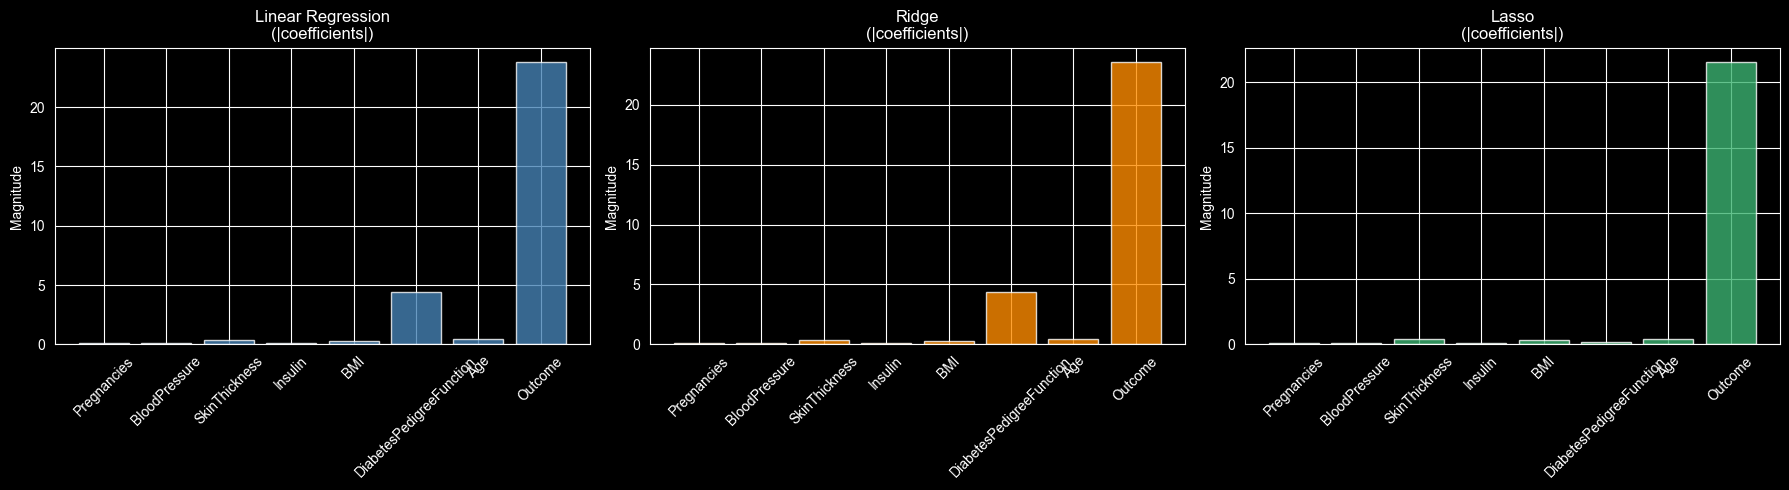

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name, color in zip(axes, models, names, colors):
    ax.bar(X.columns, np.abs(model.coef_), color=color, alpha=0.8)
    ax.set_title(f"{name}\n(|coefficients|)")
    ax.set_xticklabels(X.columns, rotation=45)
    ax.set_ylabel("Magnitude")

plt.tight_layout()
plt.show()